In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.cluster import KMeans

In [6]:
pd.set_option('display.max_columns', None)

In [7]:
df = pd.read_csv('../data/raw/Crash_Reporting_-_Drivers_Data.csv', low_memory=False)
clean_df = df.copy()

In [8]:
clean_df.shape

(210399, 39)

In [9]:
clean_df.head()

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,Related Non-Motorist,Collision Type,Weather,Surface Condition,Light,Traffic Control,Driver Substance Abuse,Non-Motorist Substance Abuse,Person ID,Driver At Fault,Injury Severity,Circumstance,Driver Distracted By,Drivers License State,Vehicle ID,Vehicle Damage Extent,Vehicle First Impact Location,Vehicle Body Type,Vehicle Movement,Vehicle Going Dir,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location
0,MCP3126006X,250037402,MONTGOMERY,Injury Crash,08/21/2025 05:21:00 PM,Maryland (State) Route,NaN,NaN,NaN,NaN,NaN,Front to Rear,Clear,Dry,Daylight,No Controls,"Not Suspect of Alcohol Use, Not Suspect of Dru...",NaN,BB3CB0F3-5A89-45FB-9516-48DDDB92B0A9,Yes,No Apparent Injury,Followed Too Closely,"Other Action (looking away from task, etc.)",MD,768C98FA-C137-47BC-BE44-EE3BA4B95F66,Superficial,Twelve O Clock,Passenger Car,Moving Constant Speed,Northbound,40,No,No,2013,KIA,SOUL,39.219796,-77.257416,"(39.219796, -77.25741635)"
1,MCP2349001B,250037516,MONTGOMERY,Property Damage Crash,08/22/2025 10:44:00 AM,Interstate (State),EISENHOWER MEMORIAL HWY,NaN,NaN,NaN,NaN,Single Vehicle,Clear,Dry,Daylight,No Controls,"Unknown, Unknown",NaN,9B84E695-215A-447E-8AA6-D3958187BBCA,No,NaN,NaN,NaN,NaN,BC322ECD-006B-4919-AAF8-3F64D934B789,Vehicle Not at Scene,Vehicle Not at Scene,NaN,Moving Constant Speed,Northbound,55,No,No,0,NaN,NaN,39.180181,-77.250657,"(39.18018079, -77.25065714)"
2,MCP296500BC,250033157,MONTGOMERY,Property Damage Crash,07/25/2025 11:55:00 AM,Bicycle Route,NaN,NEW HAMPSHIRE AVE (SB/L) NORBECK RD (WB/L) SPE...,NaN,NaN,NaN,"Sideswipe, Same Direction",Clear,Dry,Daylight,Traffic Control Signal,"Not Suspect of Alcohol Use, Not Suspect of Dru...",NaN,1D28ADF4-0DB2-4CBC-BDB0-1C1F5E7CF955,No,No Apparent Injury,NaN,Not Distracted,CO,1F4EBE18-DB94-4CA7-8D9A-88C30E90400D,Superficial,Seven O Clock,Passenger Car,Moving Constant Speed,Westbound,40,No,No,2023,LEXUS,RX,39.121219,-76.988905,"(39.12121898, -76.98890509)"
3,MCP2159003K,250037509,MONTGOMERY,Property Damage Crash,08/22/2025 10:36:00 AM,Maryland (State) Route,NaN,NaN,NaN,NaN,NaN,Front to Rear,Clear,Dry,Daylight,Flashing Traffic Control Signal,"Not Suspect of Alcohol Use, Not Suspect of Dru...",NaN,AE9A3389-3486-4199-B8F6-015D7D2E1139,Yes,No Apparent Injury,Followed Too Closely,"Manually Operating (dialing, playing game, etc.)",MD,AAEB6B5A-30B2-47D3-BF59-7F14D0A5BCAD,Disabling,Twelve O Clock,Van - Passenger (&lt;9 Seats),Slowing or Stopping,Southbound,30,No,No,2003,TOYOTA,SIENNA,39.207931,-77.141480,"(39.20793083, -77.1414795)"
4,MCP312900D6,250034573,MONTGOMERY,Property Damage Crash,08/03/2025 02:10:00 PM,NaN,NaN,NaN,Parking Lot Way PARKING LOT OF 2741 UNI...,NaN,NaN,Rear To Side,Clear,NaN,Daylight,NaN,"Unknown, Unknown",NaN,3B4FB53F-9543-48EA-8C28-14AC093FBC36,No,NaN,NaN,Unknown,NaN,B683B035-8C9F-45F7-BDB5-F9141CCF160D,Vehicle Not at Scene,Vehicle Not at Scene,Sport Utility Vehicle,Backing,Not On Roadway,0,No,No,2023,SUBARU,IMPREZA,39.039662,-77.057238,"(39.03966248, -77.05723843)"


In [10]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210399 entries, 0 to 210398
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Report Number                  210399 non-null  object 
 1   Local Case Number              210399 non-null  object 
 2   Agency Name                    210399 non-null  object 
 3   ACRS Report Type               210399 non-null  object 
 4   Crash Date/Time                210399 non-null  object 
 5   Route Type                     189797 non-null  object 
 6   Road Name                      186127 non-null  object 
 7   Cross-Street Name              170148 non-null  object 
 8   Off-Road Description           19560 non-null   object 
 9   Municipality                   19126 non-null   object 
 10  Related Non-Motorist           6871 non-null    object 
 11  Collision Type                 209814 non-null  object 
 12  Weather                       

In [11]:
clean_df.describe(include='all')

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,Related Non-Motorist,Collision Type,Weather,Surface Condition,Light,Traffic Control,Driver Substance Abuse,Non-Motorist Substance Abuse,Person ID,Driver At Fault,Injury Severity,Circumstance,Driver Distracted By,Drivers License State,Vehicle ID,Vehicle Damage Extent,Vehicle First Impact Location,Vehicle Body Type,Vehicle Movement,Vehicle Going Dir,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location
count,210399,210399,210399,210399,210399,189797,186127,170148,19560,19126,6871,209814,197043,186461,208954,181348,179079,5725,210399,210399,207766,40896,207576,196087,210399,210083,210243,207197,208732,200941,210399.000000,210399,208873,210399.000000,209281,209239,210399.000000,210399.000000,210399
unique,118644,118529,10,3,115750,19,4785,7531,13950,20,28,28,23,21,16,33,20,26,210399,3,10,813,24,81,210399,12,33,60,36,10,NaN,2,2,NaN,1963,7182,NaN,NaN,117786
top,MCP229800RC,200022715,Montgomery County Police,Property Damage Crash,12/10/2018 06:10:00 PM,Maryland (State),GEORGIA AVE,GEORGIA AVE,PARKING LOT,ROCKVILLE,PEDESTRIAN,SAME DIR REAR END,CLEAR,DRY,DAYLIGHT,NO CONTROLS,NONE DETECTED,NONE DETECTED,BB3CB0F3-5A89-45FB-9516-48DDDB92B0A9,Yes,NO APPARENT INJURY,"RAIN, SNOW, WET",NOT DISTRACTED,MD,768C98FA-C137-47BC-BE44-EE3BA4B95F66,DISABLING,TWELVE OCLOCK,PASSENGER CAR,MOVING CONSTANT SPEED,North,NaN,No,No,NaN,TOYOTA,4S,NaN,NaN,"(38.953, -77.338)"
freq,10,10,138376,135083,11,77077,11758,2390,132,9320,3880,55759,116780,120577,116150,68626,122544,3867,1,105381,141196,12172,106718,173405,1,62354,68025,119109,67240,47647,NaN,209647,205365,NaN,30491,13753,NaN,NaN,45
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.130809,NaN,NaN,1964.903056,NaN,NaN,39.083010,-77.111961,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.350810,NaN,NaN,342.493614,NaN,NaN,0.071803,0.097982,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,37.720000,-79.486000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.000000,NaN,NaN,2006.000000,NaN,NaN,39.024443,-77.189232,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.000000,NaN,NaN,2012.000000,NaN,NaN,39.074777,-77.104998,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,NaN,NaN,2016.000000,NaN,NaN,39.139659,-77.039074,NaN


In [12]:
clean_df.isnull().sum().sort_values(ascending=False)

Non-Motorist Substance Abuse     204674
Related Non-Motorist             203528
Municipality                     191273
Off-Road Description             190839
Circumstance                     169503
Cross-Street Name                 40251
Driver Substance Abuse            31320
Traffic Control                   29051
Road Name                         24272
Surface Condition                 23938
Route Type                        20602
Drivers License State             14312
Weather                           13356
Vehicle Going Dir                  9458
Vehicle Body Type                  3202
Driver Distracted By               2823
Injury Severity                    2633
Vehicle Movement                   1667
Parked Vehicle                     1526
Light                              1445
Vehicle Model                      1160
Vehicle Make                       1118
Collision Type                      585
Vehicle Damage Extent               316
Vehicle First Impact Location       156


In [13]:
print("Before:", clean_df.shape)

clean_df = clean_df.drop_duplicates()

print("After:", clean_df.shape)

Before: (210399, 39)
After: (210399, 39)


In [14]:
clean_df[clean_df['Vehicle Year']==2027]

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,Related Non-Motorist,Collision Type,Weather,Surface Condition,Light,Traffic Control,Driver Substance Abuse,Non-Motorist Substance Abuse,Person ID,Driver At Fault,Injury Severity,Circumstance,Driver Distracted By,Drivers License State,Vehicle ID,Vehicle Damage Extent,Vehicle First Impact Location,Vehicle Body Type,Vehicle Movement,Vehicle Going Dir,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location
184682,MCP33820011,240020321,MONTGOMERY,Property Damage Crash,05/01/2024 01:43:00 PM,County Route,WELLER RD,VALLEYWOOD DR,NaN,NaN,NaN,Angle,Clear,Dry,Daylight,Stop Sign,"Not Suspect of Alcohol Use, Not Suspect of Dru...",NaN,7F676FA1-11AA-4ADC-B679-EA551300D5CA,Yes,No Apparent Injury,NaN,Unknown,MD,E4258CBA-ED7D-4380-908E-3FC842F1A6B6,Superficial,One O Clock,Passenger Car,Entering Traffic Lane,NaN,25,No,No,2027,FORD,UNKNOWN,39.065235,-77.064718,"(39.065235, -77.06471833)"


# Handling non-numerical Values

To ensure high data quality for model training, we performed a standardization pass on all categorical features.

1. **Type Conversion**: Forced all values in `cat_cols` to a string format to prevent mixed-type errors.
2. **Whitespace Stripping**: Removed leading and trailing spaces that often hide in manual data entries.
3. **Case Normalization**: Converted all text to **UPPERCASE**.

In [15]:
cat_cols = clean_df.select_dtypes(include=['object', 'string','category']).columns

for col in cat_cols:
    clean_df[col] = clean_df[col].str.strip()      
    clean_df[col] = clean_df[col].str.upper()

Case Inconsistency Detection

This step identifies columns where category values differ only by letter casing, indicating inconsistent text formatting.

* **Goal**: Identify redundant categories (e.g., `Highway` vs `highway`).
* **Logic**: Compare the count of `unique()` values against the count of `str.lower().unique()` values.
* **Impact**: Reduces "cardinality noise" which improves model performance.

In [16]:
for col in cat_cols:
    lower_unique = clean_df[col].str.lower().nunique()
    actual_unique = clean_df[col].nunique()
    
    if lower_unique < actual_unique:
        print(f"{col} has case inconsistencies")

High-Cardinality Analysis

We identified **high-cardinality** categorical columns because they are difficult to analyze, can create noise in EDA, and are usually unsuitable for direct use in predictive modeling.

In [17]:
for col in cat_cols:
    unique_count = df[col].nunique()

    if unique_count > 50:
        print(f"{col}: {unique_count} unique values")

Report Number: 118644 unique values
Local Case Number: 118529 unique values
Crash Date/Time: 115750 unique values
Road Name: 4785 unique values
Cross-Street Name: 7531 unique values
Off-Road Description: 13950 unique values
Person ID: 210399 unique values
Circumstance: 813 unique values
Drivers License State: 81 unique values
Vehicle ID: 210399 unique values
Vehicle Body Type: 60 unique values
Vehicle Make: 1963 unique values
Vehicle Model: 7182 unique values
Location: 117786 unique values


We created a summary table showing the number of unique values and percentage of missing data for each categorical column.
This helps prioritize which columns need cleaning, grouping, or removal.

In [18]:
summary = pd.DataFrame({
    'column': cat_cols,
    'unique_values': [clean_df[col].nunique() for col in cat_cols],
    'missing_percent': [clean_df[col].isnull().mean()*100 for col in cat_cols]
})

summary.sort_values(by='unique_values', ascending=False)

,column,unique_values,missing_percent
18,Person ID,210399,0.000000
24,Vehicle ID,210399,0.000000
0,Report Number,118644,0.000000
1,Local Case Number,118529,0.000000
34,Location,117786,0.000000
4,Crash Date/Time,115750,0.000000
8,Off-Road Description,13895,90.703378
7,Cross-Street Name,7531,19.130794
33,Vehicle Model,7182,0.551333
6,Road Name,4785,11.536177


We examined the frequency of each category value to understand the underlying structure of the dataset. This analysis helps us:
* **Understand Data Content:** Define what types of information each column holds.
* **Identify Dominance:** Pinpoint the most frequent categories.
* **Detect Anomalies:** Surface rare values or data inconsistencies (e.g., typos or duplicate labels).

Some columns were excluded from this analysis. These typically include **unique identifiers**, **unstructured text**, or columns with **extremely high cardinality**

In [19]:
ignore_cols = [
    'Person ID	',
    'Vehicle ID',
    'Report Number',
    'Local Case Number',
    'Crash Date/Time',
    'Road Name',
    'Cross-Street Name',
    'Vehicle Model',
    'Vehicle Make',
    'Off-Road Description',
    'Circumstance',
    'Location'
]
cat_cols = clean_df.select_dtypes(include=['object', 'string']).columns

filtered_cat_cols = [col for col in cat_cols if col not in ignore_cols]

for col in filtered_cat_cols:
    print(f"\n===== {col} =====")
    print(clean_df[col].value_counts(dropna=False))
    print("Unique values:", clean_df[col].nunique())


===== Agency Name =====
Agency Name
MONTGOMERY COUNTY POLICE     138376
MONTGOMERY                    42894
ROCKVILLE POLICE DEPARTME      9839
GAITHERSBURG POLICE DEPAR      7841
ROCKVILLE                      3247
TAKOMA PARK POLICE DEPART      2993
GAITHERSBURG                   2790
MARYLAND-NATIONAL CAPITAL      1154
TAKOMA                          861
MCPARK                          404
Name: count, dtype: int64
Unique values: 10

===== ACRS Report Type =====
ACRS Report Type
PROPERTY DAMAGE CRASH    135083
INJURY CRASH              74780
FATAL CRASH                 536
Name: count, dtype: int64
Unique values: 3

===== Route Type =====
Route Type
MARYLAND (STATE)          77077
COUNTY                    55574
NaN                       20602
COUNTY ROUTE              13591
MARYLAND (STATE) ROUTE    13018
MUNICIPALITY               9380
US (STATE)                 9129
INTERSTATE (STATE)         3618
MUNICIPALITY ROUTE         2723
OTHER PUBLIC ROADWAY       1472
RAMP              

Removing Non-Informative Columns

To streamline our dataset for modeling, we have removed columns that contain only **identifiers** or **non-informative data**.

Location Column wes removed as we have same data in latitude and longitude which will be handled later

In [20]:
cols_to_drop = [
    'Person ID',
    'Vehicle ID',
    'Report Number',
    'Local Case Number',
    'Location'
]

clean_df.drop(columns=cols_to_drop, inplace=True)

leakage_columns = ['acrs_report_type','Driver At Fault','vehicle damage extent', 'Crash Location Type']

to clean = ['Municipality','Route Type']

# Data Cleaning and Null Value Handling

### 1. Agency Name

**What information it provides:**
This column represents the police agency that reported the crash. It helps identify which jurisdiction handles the majority of accident cases within the dataset.

**Problems found:**
* **Format Variations:** The same agencies were written in multiple different formats.
* **Truncated Names:** Some names were cut off due to character limits in the source system.
* **Inconsistent Spellings:** Typographical errors and different abbreviations (e.g., "P.D." vs "Police Dept").

**What we did:**
We standardized the agency names by applying a **mapping dictionary** to consolidate all variations into a single, uniform naming convention.

**Why:**
This step is crucial for data integrity. It eliminates duplicate categories, ensuring that our statistical analysis and visualizations accurately reflect the volume of incidents per jurisdiction.

In [21]:
agency_mapping = {
    'MONTGOMERY': 'MONTGOMERY COUNTY POLICE',
    'ROCKVILLE': 'ROCKVILLE POLICE',
    'ROCKVILLE POLICE DEPARTME': 'ROCKVILLE POLICE',
    'GAITHERSBURG': 'GAITHERSBURG POLICE',
    'GAITHERSBURG POLICE DEPAR': 'GAITHERSBURG POLICE',
    'TAKOMA': 'TAKOMA PARK POLICE',
    'TAKOMA PARK POLICE DEPART': 'TAKOMA PARK POLICE',
    'MCPARK': 'MARYLAND-NATIONAL CAPITAL',
    'NAN': 'UNKNOWN'
}

clean_df['Agency Name'] = clean_df['Agency Name'].replace(agency_mapping)
clean_df['Agency Name'] = clean_df['Agency Name'].fillna('UNKNOWN')
print(clean_df['Agency Name'].value_counts())

Agency Name
MONTGOMERY COUNTY POLICE     181270
ROCKVILLE POLICE              13086
GAITHERSBURG POLICE           10631
TAKOMA PARK POLICE             3854
MARYLAND-NATIONAL CAPITAL      1558
Name: count, dtype: int64


### 2. Route Type

**What information it provides:**
This field indicates the classification of the roadway where the accident occurred, such as a **major route, highway, or local road**. This is vital for understanding high-risk road types.

**Problems found:**
* **Missing Data:** Several records contained null or empty values for the route classification.

**What we did:**
We handled the missing data by imputing the value **"UNKNOWN"** for all null entries.

**Why:**
Unlike geographical coordinates or street names, route types cannot be logically inferred or "guessed" without external validation. Labeling them as "UNKNOWN" maintains dataset integrity and prevents skewed results during categorical analysis.

In [22]:
clean_df['Route Type'] = clean_df['Route Type'].fillna('UNKNOWN')
clean_df['Route Type'] = clean_df['Route Type'].replace({'NAN':'UNKNOWN'})
clean_df['Route Type'] = clean_df['Route Type'].str.strip()

In [23]:
route_mapping = {
    # High-Level Highways
    'MARYLAND (STATE) ROUTE': 'Highway/Main',
    'MARYLAND (STATE)': 'Highway/Main',
    'INTERSTATE (STATE)': 'Highway/Main',
    'US (STATE)': 'Highway/Main',
    'RAMP': 'Highway/Main',
    'SPUR': 'Highway/Main',
    
    # Local & County Roads
    'COUNTY ROUTE': 'Local/Municipal',
    'COUNTY': 'Local/Municipal',
    'MUNICIPALITY ROUTE': 'Local/Municipal',
    'MUNICIPALITY': 'Local/Municipal',
    'LOCAL ROUTE': 'Local/Municipal',
    'SERVICE ROAD': 'Local/Municipal',
    'CROSSOVER': 'Local/Municipal',
    
    # Government & Private
    'GOVERNMENT ROUTE': 'Gov/Private/Special',
    'GOVERNMENT': 'Gov/Private/Special',
    'PRIVATE ROUTE': 'Gov/Private/Special',
    'BICYCLE ROUTE': 'Gov/Private/Special',
    
    # Unknowns
    'UNKNOWN': 'Other/Unknown',
    'OTHER PUBLIC ROADWAY': 'Other/Unknown',
    'NAN' : 'Other/Unknown'
}

# 2. Apply the mapping to create a new, cleaner column
clean_df['Route Type Clean'] = clean_df['Route Type'].map(route_mapping).fillna('Other/Unknown')

### 3. Municipality

**What information it provides:**
This column identifies the specific **city, town, or jurisdiction** where the crash occurred. It is a key feature for localized spatial analysis.

**Problems found:**
* **Missing Values:** A significant number of records lacked a designated municipality.

**What we did:**
We filled all missing values in this column with the label **"UNINCORPORATED"**.

**Why:**
In traffic and administrative datasets, a missing municipality often indicates that the accident occurred in a rural area or outside of specific city limits. Using "UNINCORPORATED" provides a more accurate geographical context than a generic "Unknown" tag and prevents the loss of data during regional grouping.

In [24]:
clean_df['Municipality'] = clean_df['Municipality'].fillna('UNINCORPORATED')
clean_df['Municipality'] = clean_df['Municipality'].replace('NAN','UNINCORPORATED')

### 4. Collision Type

**What information it provides:**
This column describes the **manner of impact** (e.g., Head-on, Rear-end, Sideswipe), providing insight into the physical nature of the accident.

**Problems found:**
* **Text Variations:** Excessive unique descriptions for similar types of crashes.
* **High Cardinality:** A large number of distinct categories made the data too complex for effective statistical modeling.

**What we did:**
We performed **feature engineering** by creating a new `Collision Category` feature. This involved mapping the numerous specific descriptions into a smaller set of broader, more manageable groups.

**Why:**
Reducing cardinality minimizes "noise" in the dataset. This simplification improves the performance of predictive models and makes the resulting visualizations much easier for stakeholders to interpret.

In [25]:
def categorize_collision(x):
    if pd.isna(x):
        return "UNKNOWN"
    
    x = x.upper()
    
    if "REAR" in x:
        return "REAR_END"
    elif "HEAD ON" in x or "FRONT TO FRONT" in x:
        return "HEAD_ON"
    elif "ANGLE" in x:
        return "ANGLE"
    elif "SIDESWIPE" in x:
        return "SIDESWIPE"
    elif "SINGLE VEHICLE" in x:
        return "SINGLE_VEHICLE"
    else:
        return "OTHER"

clean_df['Collision Type Clean'] = clean_df['Collision Type'].apply(categorize_collision)
clean_df['Collision Type'] = clean_df['Collision Type'].fillna('UNKNOWN')
clean_df['Collision Type'] = clean_df['Collision Type'].replace('NAN','UNKNOWN')

### 5. Weather

**What information it provides:**
This column records the **environmental conditions** at the exact time of the crash (e.g., Clear, Raining, Sleet, Fog), which is a critical factor in determining visibility and road traction.

**Problems found:**
* **Text Variations:** Numerous redundant descriptions for similar weather states.
* **Complex Analysis:** The sheer variety of unique strings made it difficult to identify clear patterns or trends directly from the raw data.

**What we did:**
We created a new feature, **`Weather_Clean`**, by mapping specific conditions into broader, more significant categories (e.g., combining "Light Rain" and "Heavy Downpour" into "Rain").

**Why:**
Simplifying the weather data into fewer, more meaningful categories reduces model complexity. This ensures that the predictive algorithm focuses on the impact of the weather state rather than getting lost in minor descriptive nuances.

In [26]:
def clean_weather(x):
    if pd.isna(x):
        return "UNKNOWN"
    
    x = x.upper()
    
    if "CLEAR" in x:
        return "CLEAR"
    elif "CLOUD" in x:
        return "CLOUDY"
    elif "RAIN" in x:
        return "RAIN"
    elif "SNOW" in x or "SLEET" in x or "WINTRY" in x or "FREEZING" in x:
        return "WINTER"
    elif "FOG" in x or "SMOG" in x:
        return "FOG"
    elif "WIND" in x:
        return "WIND"
    elif "SAND" in x or "DIRT" in x:
        return "DUST"
    else:
        return "OTHER"
    
clean_df['Weather Clean'] = clean_df['Weather'].apply(clean_weather)  

clean_df['Weather'] = clean_df['Weather'].fillna('UNKNOWN')
clean_df['Weather'] = clean_df['Weather'].replace('NAN','UNKNOWN')

### 6. Surface Condition

**What information it provides:**
This column records the **physical state of the roadway** at the time of the crash (e.g., Dry, Wet, Snow, Ice, Sand/Gravel), which directly impacts vehicle traction and braking distance.

**Problems found:**
* **Text Inconsistencies:** Multiple variations for the same condition (e.g., "Wet" vs "Damp" vs "Standing Water").
* **Rare Categories:** Several low-frequency categories (like "Slush" or "Loose Sand") created noise without providing statistical significance.

**What we did:**
We reclassified the raw data into four primary, high-level groups: **DRY**, **WET**, **WINTER**, and **LOOSE**.

**Why:**
By consolidating the data into these four distinct categories, we can more clearly identify the major risk factors affecting road safety. This grouping ensures the model isn't distracted by rare outliers while focusing on the conditions most likely to cause an accident.


In [27]:
def clean_surface(x):
    if pd.isna(x):
        return "UNKNOWN"
    
    x = x.upper()
    
    if "DRY" in x:
        return "DRY"
    elif "WET" in x or "WATER" in x:
        return "WET"
    elif "SNOW" in x or "ICE" in x or "SLUSH" in x:
        return "WINTER"
    elif "MUD" in x or "DIRT" in x or "GRAVEL" in x or "SAND" in x or "OIL" in x:
        return "LOOSE_SURFACE"
    else:
        return "OTHER"
    
clean_df['Surface Condition Clean'] = clean_df['Surface Condition'].apply(clean_surface)

clean_df['Surface Condition'] = clean_df['Surface Condition'].fillna('UNKNOWN')
clean_df['Surface Condition'] = clean_df['Surface Condition'].replace('NAN','UNKNOWN')

### 7. Light Condition

**What information it provides:**
This column records the **lighting situation** at the time of the crash (e.g., Daylight, Dawn, Dusk, Dark - Street Lights On, Dark - No Lights).

**Problems found:**
* **Multiple Text Descriptions:** The dataset contained numerous overlapping categories describing similar levels of visibility.

**What we did:**
We simplified the lighting data into three primary categories: **DAY**, **DARK**, and **TWILIGHT**.

**Why:**
Lighting conditions have a strong, documented impact on **accident severity**. By consolidating these into three distinct groups, we can more effectively analyze how visibility levels contribute to high-impact collisions without the confusion of minor descriptive differences.

In [28]:
def clean_light(x):
    if pd.isna(x):
        return "UNKNOWN"
    
    x = x.upper()
    
    if "DAYLIGHT" in x:
        return "DAY"
    elif "DARK" in x and "LIGHTED" in x:
        return "DARK_LIGHTED"
    elif "DARK" in x and ("NO LIGHT" in x or "NOT LIGHTED" in x):
        return "DARK_NOT_LIGHTED"
    elif "DARK" in x:
        return "DARK_UNKNOWN"
    elif "DAWN" in x or "DUSK" in x:
        return "TWILIGHT"
    else:
        return "OTHER"

clean_df['Light Clean'] = clean_df['Light'].apply(clean_light)

clean_df['Light'] = clean_df['Light'].fillna('UNKNOWN')
clean_df['Light'] = clean_df['Light'].replace('NAN','UNKNOWN')

### 8. Traffic Control

**What information it provides:**
This column identifies the **traffic control device** or system present at the crash location (e.g., Traffic Signal, Stop Sign, Yield Sign, No Control).

**Problems found:**
* **Many Text Variations:** The raw data contained redundant and overly specific descriptions for similar types of traffic regulation.

**What we did:**
We simplified the data by **grouping them into broader signal types** (e.g., Signalized, Sign-Controlled, or No Control).

**Why:**
Grouping these features simplifies the analysis of how different **traffic regulations** impact accident frequency. It allows us to clearly see if certain types of control devices are more effective at preventing specific collision types than others.

In [29]:
def clean_traffic(x):
    if pd.isna(x):
        return "NO_CONTROL"
    
    x = x.upper()
    
    if "NO CONTROL" in x:
        return "NO_CONTROL"
    elif "TRAFFIC SIGNAL" in x or "TRAFFIC CONTROL SIGNAL" in x:
        return "TRAFFIC_SIGNAL"
    elif "FLASHING" in x:
        return "FLASHING_SIGNAL"
    elif "STOP" in x or "YIELD" in x:
        return "STOP_YIELD"
    elif "PEDESTRIAN" in x:
        return "PEDESTRIAN_CONTROL"
    elif "PERSON" in x:
        return "PERSON_DIRECTED"
    elif "SCHOOL" in x:
        return "SCHOOL_ZONE"
    elif "RAIL" in x:
        return "RAILROAD"
    elif "WARNING" in x:
        return "WARNING_SIGN"
    else:
        return "OTHER"

clean_df['Traffic Control Clean'] = clean_df['Traffic Control'].apply(clean_traffic)

clean_df['Traffic Control'] = clean_df['Traffic Control'].fillna('NO_CONTROL')
clean_df['Traffic Control'] = clean_df['Traffic Control'].replace('NAN','NO_CONTROL')

### 9. Driver Substance Abuse

**What information it provides:**
This column identifies whether a driver involved in the crash was **under the influence** of alcohol, drugs, or other substances at the time of the incident.

**Problems found:**
* **Complex Textual Values:** The raw data contained overly detailed descriptions, including various combinations of substances and differing legal terminology.

**What we did:**
We standardized these values by grouping them into high-level categories: **NONE**, **ALCOHOL**, **DRUG**, and **OTHER/COMBINED**.

**Why:**
Substance abuse is one of the most significant **risk factors** in accident severity. By simplifying the data, we can more clearly measure the correlation between impairment and high-impact collisions without getting bogged down in specific chemical or legal nuances.

In [30]:
def clean_substance(x):
    if pd.isna(x):
        return "UNKNOWN"
    
    x = x.upper()
    
    if "NONE DETECTED" in x or "NOT SUSPECT" in x:
        return "NONE"
    elif "COMBIN" in x:
        return "COMBINED"
    elif "ALCOHOL" in x:
        return "ALCOHOL"
    elif "DRUG" in x:
        return "DRUG"
    elif "MEDICATION" in x:
        return "MEDICATION"
    elif "UNKNOWN" in x:
        return "UNKNOWN"
    else:
        return "OTHER"
    
clean_df['Driver Substance Abuse Clean'] = clean_df['Driver Substance Abuse'].apply(clean_substance)

clean_df['Driver Substance Abuse'] = clean_df['Driver Substance Abuse'].fillna('UNKNOWN')
clean_df['Driver Substance Abuse'] = clean_df['Driver Substance Abuse'].replace('NAN','UNKNOWN')

### 10. Injury Severity (Target Column)

**What information it provides:**
This is the **Target Variable** for our analysis. It indicates the maximum level of injury sustained in the crash (e.g., No Injury, Possible Injury, Suspected Minor Injury, Suspected Serious Injury, or Fatal).

**Problems found:**
* **Missing Values:** A small percentage of records were missing the severity classification entirely.

**What we did:**
We **dropped all rows** that contained null values in this specific column.

**Why:**
The target variable is the most critical piece of information for any predictive model. **It cannot be imputed** (guessed) because filling it with a "most frequent" or "unknown" value would introduce significant bias and lead to inaccurate model training. Removing these rows ensures the integrity of our ground truth data.

In [31]:
clean_df = clean_df.dropna(subset=['Injury Severity'])

### 11. Non-Motorist Substance Abuse

**What information it provides:**
This column tracks whether **pedestrians or cyclists** involved in the crash were under the influence of alcohol, drugs, or other substances.

**Problems found:**
* **Missing Values (High Frequency):** A vast majority of the dataset contained null values for this field.
* **Complex Text:** Similar to driver data, the raw strings were overly detailed for a secondary feature.

**What we did:**
We grouped the existing entries into standard categories and filled all missing (null) values with the label **"NOT_APPLICABLE"**.

**Why:**
Most traffic accidents involve only motor vehicles. A missing value in this column typically indicates that **no non-motorist was involved** in the incident. Labeling these as "NOT_APPLICABLE" distinguishes them from actual "Unknown" cases and prevents the loss of valid vehicle-only crash data.

In [32]:
def clean_nm_substance(x):
    if pd.isna(x):
        return "NOT_APPLICABLE"
    
    x = x.upper()
    
    if "NONE DETECTED" in x or "NOT SUSPECT" in x:
        return "NONE"
    elif "COMBIN" in x:
        return "COMBINED"
    elif "ALCOHOL" in x:
        return "ALCOHOL"
    elif "DRUG" in x:
        return "DRUG"
    elif "MEDICATION" in x:
        return "MEDICATION"
    elif "UNKNOWN" in x:
        return "UNKNOWN"
    else:
        return "OTHER"
    
clean_df['Non-Motorist Substance Abuse Clean'] = clean_df['Non-Motorist Substance Abuse'].apply(clean_nm_substance)

clean_df['Non-Motorist Substance Abuse'] = clean_df['Non-Motorist Substance Abuse'].fillna('NOT_APPLICABLE')
clean_df['Non-Motorist Substance Abuse'] = clean_df['Non-Motorist Substance Abuse'].replace('NAN','NOT_APPLICABLE')

### 12. Driver Distraction

**What information it provides:**
This column identifies the specific **source of distraction** for the driver (e.g., cell phone usage, eating, talking to passengers, or external distractions).

**Problems found:**
* **Granular Textual Data:** The raw data contained dozens of highly specific distractions that were statistically infrequent on their own.

**What we did:**
We performed **feature grouping** to consolidate these into major distraction types (e.g., Electronic Device, In-Vehicle Distraction, External Distraction).

**Why:**
Simplifying these categories **reduces model complexity** and prevents the algorithm from overfitting on rare, specific distraction types. This ensures that the model identifies the broader impact of "distracted driving" rather than getting lost in the specific type of device used.

In [33]:
def categorize_distraction(x):
    if pd.isna(x) or x == 'UNKNOWN':
        return 'UNKNOWN'
    elif x == 'NOT DISTRACTED':
        return 'NO_DISTRACTION'
    elif x in [
        'LOOKED BUT DID NOT SEE',
        'INATTENTIVE OR LOST IN THOUGHT',
        'OTHER ACTION (LOOKING AWAY FROM TASK, ETC.)',
        'DISTRACTED BY OUTSIDE PERSON OBJECT OR EVENT'
    ]:
        return 'ATTENTION_RELATED'
    elif x in [
        'TALKING OR LISTENING TO CELLULAR PHONE',
        'TEXTING FROM A CELLULAR PHONE',
        'DIALING CELLULAR PHONE',
        'OTHER CELLULAR PHONE RELATED',
        'MANUALLY OPERATING (DIALING, PLAYING GAME, ETC.)'
    ]:
        return 'PHONE_RELATED'
    elif x in [
        'OTHER ELECTRONIC DEVICE (NAVIGATIONAL PALM PILOT)',
        'USING DEVICE OBJECT BROUGHT INTO VEHICLE',
        'USING OTHER DEVICE CONTROLS INTEGRAL TO VEHICLE'
    ]:
        return 'DEVICE_RELATED'
    elif x in [
        'BY OTHER OCCUPANTS',
        'BY MOVING OBJECT IN VEHICLE',
        'EATING OR DRINKING',
        'ADJUSTING AUDIO AND OR CLIMATE CONTROLS',
        'TALKING/LISTENING',
        'SMOKING RELATED'
    ]:
        return 'IN_VEHICLE_DISTRACTION'
    elif x == 'NO DRIVER PRESENT':
        return 'NO_DRIVER'
    else:
        return 'OTHER'
        
clean_df['Driver Distracted By Clean'] = clean_df['Driver Distracted By'].apply(categorize_distraction)

clean_df['Driver Distracted By'] = clean_df['Driver Distracted By'].fillna('UNKNOWN')
clean_df['Driver Distracted By'] = clean_df['Driver Distracted By'].replace('NAN','UNKNOWN')

### 13. Driver License State

**What information it provides:**
This column records the **geographic origin** of the driver's license (e.g., Maryland, Virginia, California, or international jurisdictions).

**Problems found:**
* **High Cardinality:** Having 50+ individual state categories makes it difficult to draw statistically significant conclusions for non-local drivers.

**What we did:**
We reclassified the states into three strategic groups: **In-state**, **Out-of-state**, and **International**.

**Why:**
A driver's **familiarity with local roads**, traffic laws, and regional driving culture is a documented factor in accident risk. By simplifying the data this way, we can test the hypothesis that out-of-state or international drivers may have different accident patterns than local residents.

In [34]:
us_states = {
'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN','IA','KS','KY',
'LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ','NM','NY','NC','ND',
'OH','OK','OR','PA','RI','SC','SD','TN','TX','UT','VT','VA','WA','WV','WI','WY','DC'
}

us_territories = {'PR','GU','VI','AS','MP'}

def categorize_license(x):
    if pd.isna(x) or x in ['XX','US','UM']:
        return 'UNKNOWN'
    elif x == 'MD':
        return 'IN_STATE_MD'
    elif x in us_states:
        return 'OUT_OF_STATE_US'
    elif x in us_territories:
        return 'US_TERRITORY'
    else:
        return 'INTERNATIONAL'

clean_df['Drivers License State clean'] = df['Drivers License State'].apply(categorize_license)

clean_df['Drivers License State'] = clean_df['Drivers License State'].fillna('UNKNOWN')
clean_df['Drivers License State'] = clean_df['Drivers License State'].replace('NAN','UNKNOWN')

### 14. Vehicle Damage Extent

**What information it provides:**
This column records the **physical damage sustained by the vehicle**, ranging from "Superficial" to "Destroyed/Totaled."

**Problems found:**
* **Subjective Variations:** Raw data often contains highly granular or overlapping descriptions of damage (e.g., "Functional Damage" vs. "Minor").

**What we did:**
We performed **feature grouping** to consolidate these descriptions into standardized severity levels (e.g., Minor, Functional, Disabling, Destroyed).

**Why:**
The extent of vehicle damage is a **direct indicator of crash impact** and energy. By standardizing these levels, we create a more reliable feature that correlates strongly with our target variable (Injury Severity), helping the model distinguish between low-speed bumps and high-velocity collisions.

In [35]:
def categorize_damage(x):
    if pd.isna(x) or x in ['UNKNOWN','OTHER','VEHICLE NOT AT SCENE']:
        return 'UNKNOWN'
    elif x in ['DESTROYED','DISABLING']:
        return 'SEVERE_DAMAGE'
    elif x == 'FUNCTIONAL':
        return 'MODERATE_DAMAGE'
    elif x == 'SUPERFICIAL':
        return 'MINOR_DAMAGE'
    elif x == 'NO DAMAGE':
        return 'NO_DAMAGE'
    else:
        return 'UNKNOWN'

clean_df['Vehicle Damage Extent Clean'] = clean_df['Vehicle Damage Extent'].apply(categorize_damage)

clean_df['Vehicle Damage Extent'] = clean_df['Vehicle Damage Extent'].fillna('UNKNOWN')
clean_df['Vehicle Damage Extent'] = clean_df['Vehicle Damage Extent'].replace('NAN','UNKNOWN')

### 15. Vehicle Impact Location

**What information it provides:**
This column specifies the **primary point of impact** on the vehicle (e.g., Front Bumper, Left Front Fender, Rear Quarter Panel, Roof).

**Problems found:**
* **Over-Granularity:** The dataset often identifies dozens of specific clock-points or body panels, which can be too detailed for general trend analysis.

**What we did:**
We simplified these into four primary zones: **FRONT**, **REAR**, **SIDE**, and **OTHER** (e.g., Top/Undercarriage).

**Why:**
Simplifying the impact location helps us understand the **fundamental crash mechanics**. For example, "Front" impacts are often associated with head-on collisions, while "Side" impacts often indicate T-bone accidents at intersections. This grouping allows the model to better correlate impact zones with injury severity.

In [36]:
clean_df['Vehicle First Impact Location'] = clean_df['Vehicle First Impact Location'].str.replace(" O CLOCK", " OCLOCK", regex=False)

front = ['TWELVE OCLOCK','ELEVEN OCLOCK','TEN OCLOCK',
         'ONE OCLOCK','TWO OCLOCK']

rear = ['SIX OCLOCK','FIVE OCLOCK','SEVEN OCLOCK']

side = ['THREE OCLOCK','NINE OCLOCK']

rear_side = ['FOUR OCLOCK','EIGHT OCLOCK']

top = ['ROOF TOP','TOP','UNDERSIDE']

non_collision = ['NON-COLLISION','CARGO LOSS']

def categorize_impact(x):
    if pd.isna(x) or x in ['UNKNOWN','VEHICLE NOT AT SCENE']:
        return 'UNKNOWN'
    elif x in front:
        return 'FRONT'
    elif x in rear:
        return 'REAR'
    elif x in side:
        return 'SIDE'
    elif x in rear_side:
        return 'REAR_SIDE'
    elif x in top:
        return 'ROLLOVER_TOP'
    elif x in non_collision:
        return 'NON_COLLISION'
    else:
        return 'OTHER'

clean_df['Vehicle First Impact Location Clean'] = clean_df['Vehicle First Impact Location'].apply(categorize_impact)

clean_df['Vehicle First Impact Location'] = clean_df['Vehicle First Impact Location'].fillna('UNKNOWN')
clean_df['Vehicle First Impact Location'] = clean_df['Vehicle First Impact Location'].replace('NAN','UNKNOWN')

### 16. Vehicle Body Type

**What information it provides:**
This column identifies the **classification of the vehicle** involved in the crash (e.g., Passenger Car, SUV, Pickup Truck, Motorcycle, Transit Bus).

**Problems found:**
* **Overly Granular Categories:** The raw data often listed dozens of specific body styles (e.g., 2-door Sedan, 4-door Sedan, Hatchback, Convertible) that behave similarly in a crash.

**What we did:**
We performed **feature grouping** to consolidate these into major vehicle classes: **PASSENGER**, **LTV** (Light Trucks/SUVs/Vans), **HEAVY_COMMERCIAL**, and **TWO_WHEELED**.

**Why:**
Different vehicle types have vastly different **risk patterns** and safety profiles. For example, a collision involving a heavy commercial truck carries a higher risk of severe injury than one involving two passenger cars. Grouping them ensures the model captures these fundamental physics-based differences without getting distracted by minor body style variations.

In [37]:
def categorize_body_type(x):
    if pd.isna(x) or x in ['UNKNOWN','OTHER']:
        return 'UNKNOWN'
    
    x = x.upper()
    
    if 'MOTORCYCLE' in x or 'MOPED' in x or 'AUTOCYCLE' in x:
        return 'TWO_WHEELER'
    
    elif 'BUS' in x:
        return 'BUS'
    
    elif 'TRUCK' in x and 'LIGHT' not in x and 'PICKUP' not in x:
        return 'HEAVY_TRUCK'
    
    elif 'PICKUP' in x or 'UTILITY' in x or 'VAN' in x or 'LIGHT TRUCK' in x:
        return 'SUV_PICKUP_LIGHT_TRUCK'
    
    elif 'POLICE' in x or 'AMBULANCE' in x or 'FIRE' in x:
        return 'EMERGENCY_VEHICLE'
    
    elif 'FARM' in x or 'CONSTRUCTION' in x:
        return 'INDUSTRIAL_FARM'
    
    elif 'ATV' in x or 'SNOWMOBILE' in x or 'GOLF CART' in x or 'RECREATIONAL' in x:
        return 'OFF_ROAD'
    
    elif 'PASSENGER CAR' in x or 'STATION WAGON' in x or 'LIMOUSINE' in x:
        return 'PASSENGER_VEHICLE'
    
    else:
        return 'OTHER'
        
clean_df['Vehicle Body Type Clean'] = clean_df['Vehicle Body Type'].apply(categorize_body_type)

clean_df['Vehicle Body Type'] = clean_df['Vehicle Body Type'].fillna('UNKNOWN')
clean_df['Vehicle Body Type'] = clean_df['Vehicle Body Type'].replace('NAN','UNKNOWN')

### 17. Vehicle Movement

**What information it provides:**
This column records the **dynamic action of the vehicle** immediately preceding the crash (e.g., Moving Constant Speed, Making Left Turn, Slowing or Stopping, Backing, Changing Lanes).

**Problems found:**
* **Granular Movement Data:** The raw dataset contained dozens of specific maneuvers that can be simplified into broader behavioral categories.

**What we did:**
We performed **feature grouping** to consolidate these actions into primary movement types: **STRAIGHT**, **TURNING**, **REVERSING**, and **STATIONARY/SLOWING**.

**Why:**
Driving behavior and vehicle kinematics are **primary drivers of accident causation**. By grouping these movements, we can more clearly analyze the risk levels associated with different maneuvers—for example, comparing the high-frequency risk of "Turning" maneuvers at intersections versus "Straight" travel on highways.

In [38]:
def categorize_movement(x):
    if pd.isna(x) or x in ['UNKNOWN','OTHER']:
        return 'UNKNOWN'
    
    x = x.upper()
    
    if x in ['MOVING CONSTANT SPEED','ACCELERATING','NEGOTIATING A CURVE']:
        return 'STRAIGHT_DRIVING'
    
    elif x in ['SLOWING OR STOPPING','STOPPED IN TRAFFIC LANE',
               'STOPPED IN TRAFFIC','STARTING FROM LANE',
               'STARTING FROM PARKED']:
        return 'SLOWING_OR_STOPPED'
    
    elif 'TURN' in x:
        return 'TURNING'
    
    elif x in ['CHANGING LANES','ENTERING TRAFFIC LANE','LEAVING TRAFFIC LANE']:
        return 'LANE_CHANGE'
    
    elif x in ['BACKING','PARKED','PARKING']:
        return 'REVERSING_OR_PARKING'
    
    elif x in ['PASSING','OVERTAKING/PASSING','SKIDDING']:
        return 'HIGH_RISK_MANEUVER'
    
    elif 'DRIVERLESS' in x:
        return 'DRIVERLESS'
    
    else:
        return 'OTHER'

clean_df['Vehicle Movement Clean'] = clean_df['Vehicle Movement'].apply(categorize_movement)

clean_df['Vehicle Movement'] = clean_df['Vehicle Movement'].fillna('UNKNOWN')
clean_df['Vehicle Movement'] = clean_df['Vehicle Movement'].replace('NAN','UNKNOWN')

### 18. Vehicle Direction

**What information it provides:**
This column identifies the **cardinal direction** the vehicle was traveling (e.g., Northbound, Southeast, Westbound) at the time of the incident.

**Problems found:**
* **Mixed Formats:** The raw data often contained a mix of full names ("Northbound"), abbreviations ("NB"), and specific degree headings.

**What we did:**
We standardized and simplified the data by **grouping them into the four primary cardinal directions**: **NORTH**, **SOUTH**, **EAST**, and **WEST**.

**Why:**
Grouping into cardinal directions allows for a cleaner spatial analysis of traffic flow. It helps identify if specific corridors (e.g., East-West commuter routes) experience higher accident frequencies during certain times of the day, such as sunrise or sunset, without the noise of minor directional sub-categories.

In [39]:
def clean_direction(x):
    if pd.isna(x) or x == 'UNKNOWN':
        return 'UNKNOWN'
    
    x = x.upper()
    
    if 'NORTH' in x:
        return 'NORTH'
    elif 'SOUTH' in x:
        return 'SOUTH'
    elif 'EAST' in x:
        return 'EAST'
    elif 'WEST' in x:
        return 'WEST'
    elif x == 'NOT ON ROADWAY':
        return 'NOT_ON_ROAD'
    else:
        return 'UNKNOWN'

clean_df['Vehicle Going Dir Clean'] = clean_df['Vehicle Going Dir'].apply(clean_direction)

clean_df['Vehicle Going Dir'] = clean_df['Vehicle Going Dir'].fillna('UNKNOWN')
clean_df['Vehicle Going Dir'] = clean_df['Vehicle Going Dir'].replace('NAN','UNKNOWN')

### 19. Parked Vehicle

**What information it provides:**
This column indicates whether the vehicle involved in the crash was **legally parked** at the time of the impact.

**Problems found:**
* **Sparse Missing Values:** A very small percentage of records were missing this binary indicator.

**What we did:**
We filled all null (NA) values in this column with **"NO"**.

**Why:**
In accident reporting, if a vehicle is parked, it is a significant detail that is almost always recorded. Consequently, a missing value most likely indicates a standard "in-motion" vehicle rather than a parked one. Since the number of missing values was minimal, this imputation maintains the dataset's size without introducing significant bias.

In [40]:
clean_df['Parked Vehicle'] = clean_df['Parked Vehicle'].fillna('NO')
clean_df['Parked Vehicle'] = clean_df['Parked Vehicle'].replace('NAN','NO')

### 20. Related Non-Motorist Column

**What information it provides:**
This column identifies the type of **vulnerable road user** involved in the crash, such as pedestrians, bicyclists, or individuals using wheelchairs and scooters.

**Problems found:**
* **Redundant Categories:** The raw data used multiple terms for the same role (e.g., "Bicyclist," "Cyclist," and "Pedalcyclist").
* **Multi-Value Cells:** Some records contained combined entries like "PEDESTRIAN, WHEELCHAIR," which prevents standard categorical analysis.
* **Extreme Sparsity:** Many specific categories had so few records that they acted as statistical "noise" rather than meaningful patterns.

**What we did:**
We performed **categorical consolidation** to group the values into broad, high-signal buckets:
* **PEDESTRIAN**
* **BICYCLIST**
* **SCOOTER**
* **OTHER_CONVEYANCE** (Wheelchairs, skates, etc.)
* **MULTIPLE_PARTICIPANTS**
* **UNKNOWN**

**Why:**
Grouping these values reduces model complexity and ensures each category has enough data points to be **statistically significant**. By standardizing the terminology, we improve the consistency of our Feature Importance scores and make the resulting EDA visualizations much easier to interpret for safety policy recommendations.

In [41]:
def clean_non_motorist(x):
    if pd.isna(x) or x == 'UNKNOWN':
        return 'NONE_OR_UNKNOWN'
    
    x = x.upper()
    
    # Multiple participants
    if ',' in x:
        return 'MULTIPLE'
    
    if 'PEDESTRIAN' in x or 'WHEELCHAIR' in x:
        return 'PEDESTRIAN'
    
    elif 'BICYCL' in x or 'CYCLIST' in x or 'PEDALCYCLIST' in x:
        return 'BICYCLIST'
    
    elif 'SCOOTER' in x:
        return 'SCOOTER'
    
    elif 'CONVEYANCE' in x or 'ANIMAL' in x or 'MACHINE' in x:
        return 'OTHER_CONVEYANCE'
    
    else:
        return 'OTHER'

clean_df['Related Non-Motorist Clean'] = clean_df['Related Non-Motorist'].apply(clean_non_motorist)

clean_df['Related Non-Motorist'] = clean_df['Related Non-Motorist'].fillna('UNKNOWN')
clean_df['Related Non-Motorist'] = clean_df['Related Non-Motorist'].replace('NAN','UNKNOWN')

### HIGH CARDINALITY FEATURE CLEANING & FEATURE ENGINEERING

We selected the remaining categorical columns that were ignored earlier due to high cardinality.

In [42]:
remaining_cols = [col for col in ignore_cols if col.strip() not in cols_to_drop]

In [43]:
summary = pd.DataFrame({
    'column': remaining_cols,
    'unique_values': [clean_df[col].nunique() for col in remaining_cols],
    'missing_percent': [clean_df[col].isnull().mean()*100 for col in remaining_cols]
})

summary.sort_values(by='unique_values', ascending=False)

,column,unique_values,missing_percent
0,Crash Date/Time,114823,0.000000
5,Off-Road Description,13429,90.917667
2,Cross-Street Name,7520,18.365373
3,Vehicle Model,7170,0.152575
1,Road Name,4742,11.257857
4,Vehicle Make,1962,0.132360
6,Circumstance,798,80.417393


### 1. Crash Date/Time Feature Engineering

**What information it provides:**
This column stores the **exact timestamp** (Year-Month-Day Hour:Minute) of the accident.

**Problems found:**
* **Non-Numeric Format:** ML models cannot process raw strings or timestamp objects directly.
* **High Cardinality:** With thousands of unique timestamps, the model cannot find meaningful patterns without transformation.

**What we did:**
We extracted several new, high-value features from the raw timestamp:
* **Hour of Day:** To capture morning/evening rush hour patterns.
* **Day of Week:** To distinguish between weekday commutes and weekend traffic.
* **Month:** To account for seasonal variations (e.g., winter vs. summer).

**Why:**
Feature engineering transforms a single complex column into multiple **behavioral indicators**. For example, the model can now "see" that accidents occurring at 2:00 AM on a Saturday (Weekend/Late Night) have different characteristics and severity risks than those at 8:00 AM on a Tuesday (Weekday/Rush Hour).

In [44]:
clean_df['Crash Date/Time'] = pd.to_datetime(clean_df['Crash Date/Time'],format='%m/%d/%Y %I:%M:%S %p')

clean_df['Crash Hour'] = clean_df['Crash Date/Time'].dt.hour
clean_df['Crash Dayofweek'] = clean_df['Crash Date/Time'].dt.dayofweek
clean_df['Is Weekend'] = clean_df['Crash Dayofweek'].isin([5,6]).astype(int)
clean_df['Crash Month'] = clean_df['Crash Date/Time'].dt.month

In [45]:
bins = [-1, 6, 10, 16, 20, 24] 
labels = ['Late Night', 'Morning Rush', 'Mid-Day', 'Evening Rush', 'Night']
clean_df['Time Of Day Clean'] = pd.cut(clean_df['Crash Hour'], bins=bins, labels=labels)

In [46]:
day_mapping = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}
clean_df['Crash Dayofweek Clean'] = clean_df['Crash Dayofweek'].map(day_mapping)

In [47]:
month_mapping = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
clean_df['Crash Month Clean'] = clean_df['Crash Month'].map(month_mapping)

In [48]:
bins = [0, 2, 5, 8, 11, 12]
labels = ['Winter', 'Spring', 'Summer', 'Fall', 'Winter']

clean_df['Crash Season Clean'] = pd.cut(clean_df['Crash Month'], bins=bins, labels=labels, ordered=False)


In [49]:
clean_df.drop(columns=['Crash Date/Time'], inplace=True)

### 2. Off-Road Description → Location Type

**What information it provides:**
This column specifies the **exact environment** of the crash when it occurs away from the main travel lanes, such as in a parking lot, driveway, alley, shoulder, or trail.

**Problems found:**
* **Free Text Field:** The data was entered manually, leading to inconsistent naming and typos.
* **Extremely Messy:** Hundreds of variations for the same physical location (e.g., "Parking Lot" vs. "Pkg Lot").
* **High Cardinality:** Too many unique strings for a model to learn from effectively.

**What we did:**
We performed a two-step transformation:
1. **Off-Road Category:** Grouped similar descriptions into clean buckets (e.g., "PRIVATE_PROPERTY", "ROADSIDE_SHOULDER", "NON_MOTORIST_PATH").
2. **Crash Location Type:** Created a high-level binary/categorical indicator to distinguish between **ON_ROAD** and **OFF_ROAD** incidents.

**Why:**
Converting messy, unstructured text into structured features dramatically improves **Model Performance**. It allows the algorithm to understand that a crash in a "Parking Lot" carries different risk profiles and expected speeds than one occurring on a "Shoulder" of a high-speed highway. This also provides much-needed **EDA clarity** when visualizing where accidents are most frequent.

In [50]:
clean_df['Crash Location Type'] = np.where(
    clean_df['Off-Road Description'].isna(), 
    'ON_ROAD', 
    'OFF_ROAD'
)

In [51]:
def classify_location(text):
    if pd.isna(text):
        return "UNKNOWN"
    
    text = text.upper()
    
    if "PARKING GARAGE" in text:
        return "PARKING_GARAGE"
    elif "PARKING LOT" in text or "PKG LOT" in text or "PL " in text:
        return "PARKING_LOT"
    elif "DRIVEWAY" in text or "DRIVE THRU" in text:
        return "DRIVEWAY"
    elif "ALLEY" in text:
        return "ALLEY"
    elif "SHOULDER" in text:
        return "SHOULDER"
    elif "TRAIL" in text or "PATH" in text:
        return "TRAIL"
    elif "BUS" in text:
        return "BUS_AREA"
    elif "SCHOOL" in text:
        return "SCHOOL_AREA"
    elif "GARAGE" in text:
        return "GARAGE"
    else:
        return "OTHER"
    
clean_df['Off-Road Description Clean'] = clean_df['Off-Road Description'].apply(classify_location)    

In [52]:

clean_df['Off-Road Description'] = clean_df['Off-Road Description'].fillna('UNKNOWN')
clean_df['Off-Road Description'] = clean_df['Off-Road Description'].replace('NAN','UNKNOWN')

### 3. Vehicle Make & Model Removal

**What information it provides:**
These columns record the **specific brand** (e.g., Toyota, Ford, Tesla) and the **specific model name** (e.g., Camry, F-150, Model 3) of the vehicles involved in the crash.

**Problems found:**
* **Extremely High Cardinality:** There are thousands of unique make/model combinations, which would require massive amounts of data to reach statistical significance.
* **Very Messy Text:** Frequent typos, inconsistent naming (e.g., "Chev", "Chevy", "Chevrolet"), and varied trim levels.
* **Irrelevant for Severity:** While a specific brand might matter for insurance, the exact model name is rarely a primary predictor of injury severity compared to the vehicle's size and speed.

**What we did:**
We **dropped both columns** entirely from the final dataset.

**Why:**
We followed a core data science principle: **Drop features that are noisy, irrelevant, and too complex to clean.** Since we already retained **Vehicle Body Type** (e.g., Passenger Car vs. SUV), we have already captured the physical characteristics that actually influence crash physics. Keeping Make and Model would only lead to model "overfitting" on specific car brands.

In [53]:
clean_df.drop(columns=['Vehicle Model'], inplace=True)

In [54]:
clean_df.drop(columns=['Vehicle Make'], inplace=True)

### 4. Road Category & Cross-Road Category

**What information it provides:**
These columns record the **specific street names** (e.g., "I-95", "Main St", "Oak Lane") where the crash occurred and the nearest intersecting street.

**Problems found:**
* **Street Name Complexity:** Storing data as specific street names results in **thousands of unique values**, making it impossible for a model to generalize patterns.
* **Lack of Context:** A street name alone doesn't tell the model the speed limit, traffic volume, or road design.

**What we did:**
We converted the raw street names into a structured **Road Type** feature by mapping them to their functional classifications:
* **HIGH_SPEED:** (Interstates, Freeways, Expressways)
* **ARTERIAL:** (Major boulevards and multi-lane thoroughfares)
* **RESIDENTIAL:** (Neighborhood streets)
* **LOCAL:** (Secondary roads and connectors)
* **RAMP:** (Entrance and exit connectors)

**Why:**
Road type is a **major accident risk factor**. For example, accidents on **High-Speed** roads are statistically correlated with higher energy impacts and increased severity, while **Residential** roads are linked to lower-speed collisions and pedestrian interactions. This engineered feature allows the model to learn the "physics" of the location rather than just memorizing a list of street names.

In [55]:
def derive_road_category(name):
    if pd.isna(name):
        return "UNKNOWN"
    
    name = name.upper()
    
    if "RAMP" in name:
        return "RAMP"
    
    if any(k in name for k in ["HWY", "FWY", "EXPY", "PKWY", "PIKE"]):
        return "HIGH_SPEED"
    
    if any(k in name for k in ["BLVD", "AVE"]):
        return "ARTERIAL"
    
    if any(k in name for k in ["CT", "CIR", "TER", "PL", "LN", "LOOP", "TRL"]):
        return "RESIDENTIAL"
    
    return "LOCAL"

clean_df["Road Category Clean"] = clean_df["Road Name"].apply(derive_road_category)
clean_df["Cross Road Category Clean"] = clean_df["Cross-Street Name"].apply(derive_road_category)

clean_df['Road Name'] = clean_df['Road Name'].fillna('UNKNOWN')
clean_df['Road Name'] = clean_df['Road Name'].replace({'NAN':'UNKNOWN'})
clean_df['Cross-Street Name'] = clean_df['Cross-Street Name'].fillna('UNKNOWN')
clean_df['Cross-Street Name'] = clean_df['Cross-Street Name'].replace({'NAN':'UNKNOWN'})

### 5. Circumstance Column Removal

**What information it provides:**
This column contains a **narrative text description** providing a detailed account of the specific circumstances surrounding the accident (e.g., "Vehicle 1 swerved to avoid a deer and struck a guardrail").

**Problems found:**
* **Unstructured Free Text:** Unlike categorical data, this is raw human language with no set format.
* **Extremely Messy:** Contains typos, varying levels of detail, and inconsistent terminology from different reporting officers.
* **Incompatible with Tabular ML:** Standard machine learning algorithms (like Random Forest or XGBoost) cannot process raw paragraphs without advanced Natural Language Processing (NLP).

**What we did:**
We **dropped the column** from our feature set.

**Why:**
We followed a standard **industry practice**: **Drop free-text columns** unless you are specifically performing a multi-modal NLP project. The relevant physical factors described in these narratives (like "hitting a guardrail" or "swerving") are already captured by more structured features like *Collision Type*, *Vehicle Movement*, and *Equipment Problems*. Removing this column prevents "noise" and significantly reduces the memory footprint of the dataset.

In [56]:
clean_df.drop(columns=['Circumstance'], inplace=True)

# Handling Numeric Values

We selected all numeric columns from the dataset.

In [57]:
num_col = clean_df.select_dtypes(exclude=['object', 'string']).columns.tolist()

In [58]:
summary = pd.DataFrame({
    'column': num_col,
    'unique_values': [clean_df[col].nunique() for col in num_col],
    'missing_percent': [clean_df[col].isnull().mean()*100 for col in num_col]
})

summary.sort_values(by='unique_values', ascending=False)

,column,unique_values,missing_percent
3,Longitude,107090,0.0
2,Latitude,104908,0.0
1,Vehicle Year,145,0.0
4,Crash Hour,24,0.0
0,Speed Limit,16,0.0
7,Crash Month,12,0.0
5,Crash Dayofweek,7,0.0
8,Time Of Day Clean,5,0.0
9,Crash Season Clean,4,0.0
6,Is Weekend,2,0.0


### 1. Latitude & Longitude → Location Clustering

**What information it provides:**
These columns provide the **exact geographic coordinates** (GPS points) where each crash occurred.

**Problems found:**
* **Infinite Granularity:** Every coordinate is slightly different, resulting in thousands of unique points that a model cannot generalize.
* **Non-Linear Relationships:** Raw numbers for Latitude and Longitude don't represent "distance" or "proximity" in a way that standard ML algorithms can easily interpret.
* **Noise:** GPS drift and minor recording errors create "scatter" that obscures high-traffic patterns.

**What we did:**
We applied **Geospatial Clustering** (such as K-Means or DBSCAN) to group these individual points into distinct **Accident Hotspot Regions**. Instead of raw coordinates, each crash is now assigned to a specific "Zone ID."

**Why:**
This is a standard real-world technique that converts raw numbers into **spatial intelligence**. By grouping coordinates into clusters, we:
* **Reduce Dimensionality:** We replace two complex float columns with one categorical "Region" feature.
* **Detect High-Risk Zones:** The model can now identify if a specific intersection or neighborhood is statistically more dangerous, regardless of the exact GPS coordinate.
* **Improve Interpretability:** It allows for clearer visualizations during EDA, showing where safety resources should be prioritized.

In [59]:


kmeans = KMeans(n_clusters=20, random_state=42)

clean_df['Location Cluster Clean'] = kmeans.fit_predict(
    clean_df[['Latitude', 'Longitude']]
)

In [60]:
clean_df['Location Cluster Clean'].unique().tolist()

[15, 16, 9, 7, 0, 11, 6, 1, 12, 5, 3, 19, 14, 2, 8, 18, 13, 10, 17, 4]

### 2. Vehicle Year → Vehicle Age

**What information it provides:**
This column records the **manufacturing year** of the vehicle involved in the accident.

**Problems found:**
* **Invalid Data/Outliers:** The raw data contained "placeholder" values like `0`, `9999`, or `1111`, which are physically impossible.
* **Unrealistic Years:** Some entries listed vehicles from the future or from eras before mass automotive production.
* **Static Value:** A year (e.g., 2015) is less useful to a model than the relative **age** of the vehicle at the time of the crash.

**What we did:**
1. **Transformed to Age:** We calculated `Vehicle Age = Current Year (2026) - Vehicle Year`.
2. **Advanced Imputation:** Instead of a simple fill, we used **Group-wise Median Imputation**. We calculated the median age for each *Vehicle Body Type* and used that to fill the missing/invalid values.

**Why:**
* **Robustness:** The **Median** is far more robust to extreme outliers (like year 9999) than the Mean.
* **Domain Accuracy:** Different vehicle types have different lifespans. For example, the typical age of a commercial transit bus differs from that of a private passenger car. Grouping by body type ensures our "best guess" for missing data is contextually accurate.
* **Predictive Power:** Vehicle age is a proxy for **safety technology**. Older vehicles may lack modern crumple zones or electronic stability control, making age a significant predictor of injury severity.

In [61]:
current_year = datetime.now().year

def clean_vehicle_year(year):
    if 1950 <= year <= current_year:
        return year
    else:
        return np.nan

clean_df['Vehicle Year Clean'] = clean_df['Vehicle Year'].apply(clean_vehicle_year)

In [62]:
clean_df['Vehicle Age'] = current_year - clean_df['Vehicle Year Clean']

In [63]:
clean_df['Vehicle Age'].isnull().sum()

np.int64(4512)

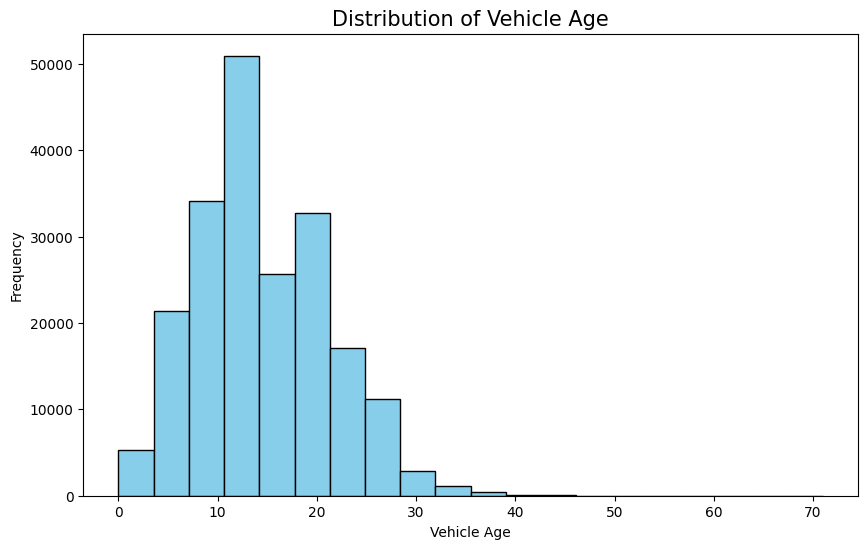

In [64]:
column_name = 'Vehicle Age'

plt.figure(figsize=(10, 6))
plt.hist(clean_df[column_name], bins=20, color='skyblue', edgecolor='black')

# Adding labels and title
plt.title(f'Distribution of {column_name}', fontsize=15)
plt.xlabel(column_name)
plt.ylabel('Frequency')

plt.show()

In [65]:
clean_df['Vehicle Age'] = clean_df.groupby('Vehicle Body Type Clean')['Vehicle Age']\
                                  .transform(lambda x: x.fillna(x.median()))

clean_df['Vehicle Year Clean']=clean_df['Vehicle Year Clean'].fillna(current_year-clean_df['Vehicle Age']) 

### 3. Speed Limit Cleaning

**What information it provides:**
This column represents the **legal maximum speed** permitted on the road where the accident took place. This is a critical feature for calculating the potential kinetic energy involved in a collision.

**Problems found:**
* **Invalid Zero Values:** Many records showed a speed limit of `0`, which is physically impossible for active roadways.
* **Missing Data:** Several entries were left blank, creating gaps in a primary predictive feature.
* **Skewed Distribution:** Speed limit data is rarely a "normal" bell curve; it tends to cluster around specific increments (e.g., 25, 35, 55, 65 mph), often with a heavy tail toward lower or higher speeds.

**What we did:**
We replaced all zero values and missing entries with the **Median Speed Limit**.

**Why we used the Median:**
* **Robustness:** Unlike the mean (average), the median is not pulled away by extreme outliers or "fat tails" in the distribution.
* **Integrity of Increments:** Since speed limits exist in specific 5 or 10 mph steps, the median is more likely to represent a "real-world" speed limit than an average (which might result in a non-existent speed limit like 38

In [66]:
clean_df['Speed Limit'] = clean_df['Speed Limit'].replace(0, np.nan)

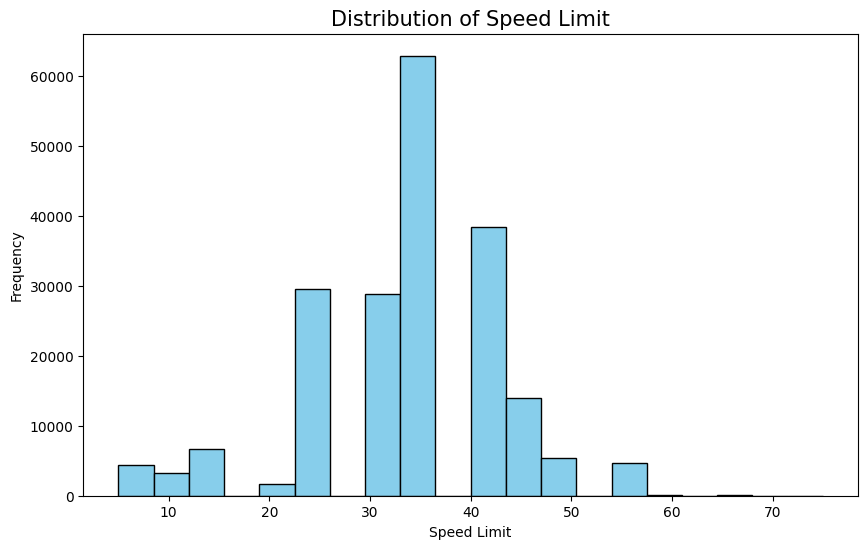

In [67]:
column_name = 'Speed Limit'

plt.figure(figsize=(10, 6))
plt.hist(clean_df[column_name], bins=20, color='skyblue', edgecolor='black')

# Adding labels and title
plt.title(f'Distribution of {column_name}', fontsize=15)
plt.xlabel(column_name)
plt.ylabel('Frequency')

plt.show()

In [68]:
clean_df['Speed Limit'] = clean_df['Speed Limit'].fillna(clean_df['Speed Limit'].median())

In [69]:
clean_df.isnull().sum()

Agency Name                  0
ACRS Report Type             0
Route Type                   0
Road Name                    0
Cross-Street Name            0
                            ..
Road Category Clean          0
Cross Road Category Clean    0
Location Cluster Clean       0
Vehicle Year Clean           0
Vehicle Age                  0
Length: 61, dtype: int64

In [70]:
clean_df.to_csv('../data/interim/Crash_Reporting_-_Drivers_Data_cleaned.csv', index=False, quoting=1)

In [71]:
clean_df.shape

(207766, 61)